In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/user/OneDrive/Desktop/nexthikes_project_3/retail_large_dataset.csv")
df

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [4]:
#summary stats

In [5]:
df.describe().round()

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0
mean,42.0,30165.0,3.0,15.0,64166.0,6.0
std,14.0,17140.0,1.0,9.0,49969.0,3.0
min,18.0,500.0,1.0,0.0,357.0,1.0
25%,30.0,15375.0,1.0,7.0,24705.0,3.0
50%,42.0,30148.0,3.0,15.0,49752.0,5.0
75%,54.0,44957.0,4.0,23.0,94046.0,8.0
max,65.0,59998.0,4.0,30.0,239980.0,10.0


In [6]:
#missing values

In [7]:
df.isnull().sum()       #percentge of missing data df.isnull().sum()/len(df)*100

customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64

In [8]:
#percentge of missing data

In [9]:
df.isnull().sum()/len(df)*100

customer_id            0.0
age                    0.0
gender                 0.0
city                   0.0
state                  0.0
customer_segment       0.0
order_id               0.0
order_date             0.0
product_category       0.0
product_subcategory    0.0
product_price          0.0
quantity               0.0
discount_percentage    0.0
final_price            0.0
payment_method         0.0
shipping_type          0.0
delivery_days          0.0
return_status          0.0
dtype: float64

In [10]:
df.shape

(100000, 18)

In [11]:
#finding duplicates

In [12]:
df[df.duplicated()].shape

(0, 18)

In [13]:
#finding if duplicate value in primary key

In [14]:
df["customer_id"].value_counts()

customer_id
C109983    1
C109982    1
C109981    1
C109980    1
C109979    1
          ..
C10004     1
C10003     1
C10002     1
C10001     1
C10000     1
Name: count, Length: 100000, dtype: int64

In [15]:
#looking for unique values present in catagorical data

In [16]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(col)
        print(df[col].value_counts())       #give frequency
        print("-"*50)

gender
gender
Male      50111
Female    49889
Name: count, dtype: int64
--------------------------------------------------
state
state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64
--------------------------------------------------
customer_segment
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64
--------------------------------------------------
product_category
product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64
--------------------------------------------------
quantity
quantity
4    25146
1    25080
3    24967
2    24807
Name: count, dtype: int64
--------------------------------------------------
payment_method
payment_me

In [17]:
df["age"].unique()

array([56, 36, 20, 39, 31, 24, 19, 51, 57, 42, 61, 50, 43, 49, 45, 58, 59,
       54, 40, 41, 23, 52, 37, 35, 25, 65, 64, 53, 60, 18, 47, 21, 28, 34,
       62, 26, 30, 55, 32, 27, 46, 22, 63, 38, 44, 29, 48, 33])

In [18]:
#changing datatype for order_date

In [19]:
df["order_date"] = pd.to_datetime(df["order_date"])
df['year'] = df['order_date'].dt.year

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          100000 non-null  object        
 1   age                  100000 non-null  int64         
 2   gender               100000 non-null  object        
 3   city                 100000 non-null  object        
 4   state                100000 non-null  object        
 5   customer_segment     100000 non-null  object        
 6   order_id             100000 non-null  object        
 7   order_date           100000 non-null  datetime64[ns]
 8   product_category     100000 non-null  object        
 9   product_subcategory  100000 non-null  object        
 10  product_price        100000 non-null  int64         
 11  quantity             100000 non-null  int64         
 12  discount_percentage  100000 non-null  int64         
 13  final_price    

In [21]:
df.describe().round()

,age,order_date,product_price,quantity,discount_percentage,final_price,delivery_days,year
count,100000.0,100000,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0
mean,42.0,2024-06-29 02:48:38.304000,30165.0,3.0,15.0,64166.0,6.0,2024.0
min,18.0,2023-01-01 00:00:00,500.0,1.0,0.0,357.0,1.0,2023.0
25%,30.0,2023-09-30 00:00:00,15375.0,1.0,7.0,24705.0,3.0,2023.0
50%,42.0,2024-06-28 00:00:00,30148.0,3.0,15.0,49752.0,5.0,2024.0
75%,54.0,2025-03-30 00:00:00,44957.0,4.0,23.0,94046.0,8.0,2025.0
max,65.0,2025-12-30 00:00:00,59998.0,4.0,30.0,239980.0,10.0,2025.0
std,14.0,NaN,17140.0,1.0,9.0,49969.0,3.0,1.0


In [22]:
#univariate analysis

In [23]:
df.mean(numeric_only = True)

age                       41.561830
product_price          30164.526720
quantity                   2.501790
discount_percentage       15.009890
final_price            64165.723382
delivery_days              5.505540
year                    2023.994270
dtype: float64

In [24]:
df.median(numeric_only = True)

age                       42.00
product_price          30148.00
quantity                   3.00
discount_percentage       15.00
final_price            49752.39
delivery_days              5.00
year                    2024.00
dtype: float64

In [25]:
df.std(numeric_only = True)

age                       13.852439
product_price          17139.679807
quantity                   1.120058
discount_percentage        8.953296
final_price            49969.280150
delivery_days              2.872868
year                       0.815171
dtype: float64

In [26]:
df.min(numeric_only = True)

age                      18.0
product_price           500.0
quantity                  1.0
discount_percentage       0.0
final_price             357.0
delivery_days             1.0
year                   2023.0
dtype: float64

In [27]:
df.max(numeric_only = True)

age                        65.0
product_price           59998.0
quantity                    4.0
discount_percentage        30.0
final_price            239980.0
delivery_days              10.0
year                     2025.0
dtype: float64

In [28]:
def unistats(df):
    output_df = pd.DataFrame(columns=['Count', 'Missing Values','Unique Values', 'Dtype', 'Mean', 'Median', 'Mode', 'Min', 'Max', 'Std Dev', '25th Percentile', '75th Percentile', 'Skewness', 'Kurtosis'])
    for column in df:
      if pd.api.types.is_numeric_dtype(df[column]):
        # Fixed order of values to match column order
        output_df.loc[column] = [
            df[column].count(),                  # Count
            df[column].isnull().sum(),           # Missing Values
            df[column].nunique(),                # Unique Values
            df[column].dtype,                    # Dtype
            df[column].mean(),                   # Mean
            df[column].median(),                 # Median
            df[column].mode()[0] if not df[column].mode().empty else None,  # Mode
            df[column].min(),                    # Min
            df[column].max(),                    # Max
            df[column].std(),                    # Std Dev
            df[column].quantile(0.25),           # 25th Percentile
            df[column].quantile(0.75),           # 75th Percentile
            df[column].skew(),                   # Skewness
            df[column].kurt()                    # Kurtosis
        ]
      else:
        # Added a value for Mode to match the 14 columns
        output_df.loc[column] = [
            df[column].count(),                  # Count
            df[column].isnull().sum(),           # Missing Values
            df[column].nunique(),                # Unique Values
            df[column].dtype,                    # Dtype
            "-",                                 # Mean
            "-",                                 # Median
            df[column].mode()[0] if not df[column].mode().empty else None,  # Mode
            "-",                                 # Min
            "-",                                 # Max
            "-",                                 # Std Dev
            "-",                                 # 25th Percentile
            "-",                                 # 75th Percentile
            "-",                                 # Skewness
            "-"                                  # Kurtosis
        ]
              
    return output_df.sort_values(by=["Unique Values"], ascending=False)

# test the function
import pandas as pd
pd.set_option('display.max_rows', 18)  # to display all rows in the output
pd.set_option('display.max_columns', 18)  # to display all columns in the output
unistats(df)

,Count,Missing Values,Unique Values,Dtype,Mean,Median,Mode,Min,Max,Std Dev,25th Percentile,75th Percentile,Skewness,Kurtosis
customer_id,100000,0,100000,object,-,-,C10000,-,-,-,-,-,-,-
order_id,100000,0,100000,object,-,-,O100000,-,-,-,-,-,-,-
final_price,100000,0,97092,float64,64165.723382,49752.39,9959.04,357.0,239980.0,49969.28015,24705.0,94046.07,0.934747,0.169047
product_price,100000,0,48449,int64,30164.52672,30148.0,41274,500,59998,17139.679807,15375.0,44957.0,0.003249,-1.195106
order_date,100000,0,1095,datetime64[ns],-,-,2023-04-12 00:00:00,-,-,-,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
customer_segment,100000,0,3,object,-,-,New,-,-,-,-,-,-,-
year,100000,0,3,int32,2023.99427,2024.0,2024,2023,2025,0.815171,2023.0,2025.0,0.01051,-1.495044
gender,100000,0,2,object,-,-,Male,-,-,-,-,-,-,-
shipping_type,100000,0,2,object,-,-,Express,-,-,-,-,-,-,-


In [29]:
#outliers

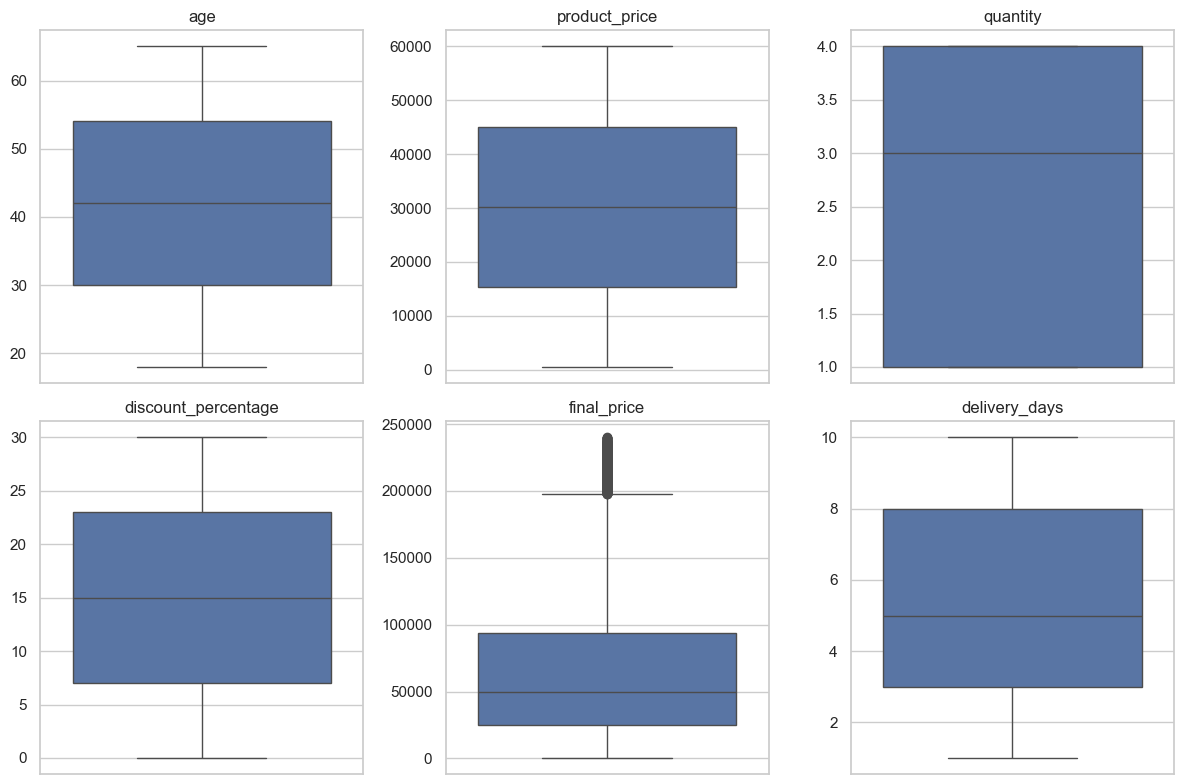

In [30]:
# Visualize potential outliers with boxplots for key numeric columns


sns.set_theme(style='whitegrid')
cols_to_plot = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']

plt.figure(figsize=(12, 8))
for i, col_name in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col_name], color='#4c72b0')
    plt.title(col_name)
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [31]:
# the boxplots show that final_price has the most obvious high-end outliers; the other numeric columns look pretty bounded (and many are naturally capped: quantity maxes at 4, discount_percentage at 30, age at 65, delivery_days at 10).

In [32]:
# Compute outlier flags using IQR and Z-score methods and summarize counts per column


num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']

# IQR bounds
iqr_bounds = {}
iqr_outlier_flags = pd.DataFrame(index=df.index)
for col_name in num_cols:
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr_val = q3 - q1
    lower = q1 - 1.5 * iqr_val
    upper = q3 + 1.5 * iqr_val
    iqr_bounds[col_name] = {'q1': q1, 'q3': q3, 'iqr': iqr_val, 'lower': lower, 'upper': upper}
    iqr_outlier_flags[col_name] = (df[col_name] < lower) | (df[col_name] > upper)

# Z-score (standard) with threshold 3
z_thresh = 3.0
zscore_flags = pd.DataFrame(index=df.index)
for col_name in num_cols:
    col_vals = df[col_name].astype(float)
    mean_val = col_vals.mean()
    std_val = col_vals.std(ddof=0)
    if std_val == 0:
        zscore_flags[col_name] = False
    else:
        z_vals = (col_vals - mean_val) / std_val
        zscore_flags[col_name] = z_vals.abs() > z_thresh

# Summaries
iqr_counts = iqr_outlier_flags.sum().sort_values(ascending=False)
z_counts = zscore_flags.sum().sort_values(ascending=False)

bounds_df = pd.DataFrame(iqr_bounds).T[['q1','q3','iqr','lower','upper']]

print(bounds_df)
print(iqr_counts)
print(z_counts)

                          q1        q3       iqr      lower       upper
age                     30.0     54.00     24.00     -6.000      90.000
product_price        15375.0  44957.00  29582.00 -28998.000   89330.000
quantity                 1.0      4.00      3.00     -3.500       8.500
discount_percentage      7.0     23.00     16.00    -17.000      47.000
final_price          24705.0  94046.07  69341.07 -79306.605  198057.675
delivery_days            3.0      8.00      5.00     -4.500      15.500
final_price            1335
age                       0
product_price             0
quantity                  0
discount_percentage       0
delivery_days             0
dtype: int64
final_price            503
age                      0
product_price            0
quantity                 0
discount_percentage      0
delivery_days            0
dtype: int64


In [33]:
#Using IQR, only final_price was flagged with outliers:

#final_price IQR upper bound ≈ 198,057.675
#1,335 rows were above that upper bound (IQR outliers)
#All other numeric fields had 0 IQR outliers (their bounds were so wide or the data is capped such that none fell outside)
#This is why the boxplots mostly look “clean” except for final_price.

In [34]:
#With cutoff 3.0, again mainly final_price:

#503 rows flagged as Z-score outliers for final_price
#All other numeric fields had 0 Z-score outliers
#Why fewer than IQR? Because IQR is robust and depends on quartiles (often flags more tail values in skewed distributions), while Z-score assumes something closer to normality (skew can reduce its usefulness).

In [35]:


num_cols = ['age','product_price','quantity','discount_percentage','final_price','delivery_days']

# --- IQR detection ---
iqr_info = {}
iqr_flags = pd.DataFrame(index=df.index)

for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    iqr_info[c] = {'q1': q1, 'q3': q3, 'iqr': iqr, 'low': low, 'high': high}
    iqr_flags[c] = (df[c] < low) | (df[c] > high)

# counts
iqr_outlier_counts = iqr_flags.sum().sort_values(ascending=False)

# --- Z-score detection ---
z_thresh = 3.0
z_flags = pd.DataFrame(index=df.index)

for c in num_cols:
    vals = df[c].astype(float)
    mu = vals.mean()
    sig = vals.std(ddof=0)
    if sig == 0:
        z_flags[c] = False
    else:
        z = (vals - mu) / sig
        z_flags[c] = z.abs() > z_thresh

z_outlier_counts = z_flags.sum().sort_values(ascending=False)

iqr_outlier_counts, z_outlier_counts

(final_price            1335
 age                       0
 product_price             0
 quantity                  0
 discount_percentage       0
 delivery_days             0
 dtype: int64,
 final_price            503
 age                      0
 product_price            0
 quantity                 0
 discount_percentage      0
 delivery_days            0
 dtype: int64)

In [36]:
#IQR capping for final_price

In [37]:
df_capped = df.copy()
cap_high = iqr_info['final_price']['high']
cap_low = iqr_info['final_price']['low']

df_capped['final_price'] = df_capped['final_price'].clip(lower=cap_low, upper=cap_high)

198057.675
1335
0
1.335
              before  after_iqr_cap
count  100000.000000  100000.000000
mean    64165.723382   63978.839890
std     49969.280150   49425.719614
min       357.000000     357.000000
25%     24705.000000   24705.000000
50%     49752.390000   49752.390000
75%     94046.070000   94046.070000
max    239980.000000  198057.675000


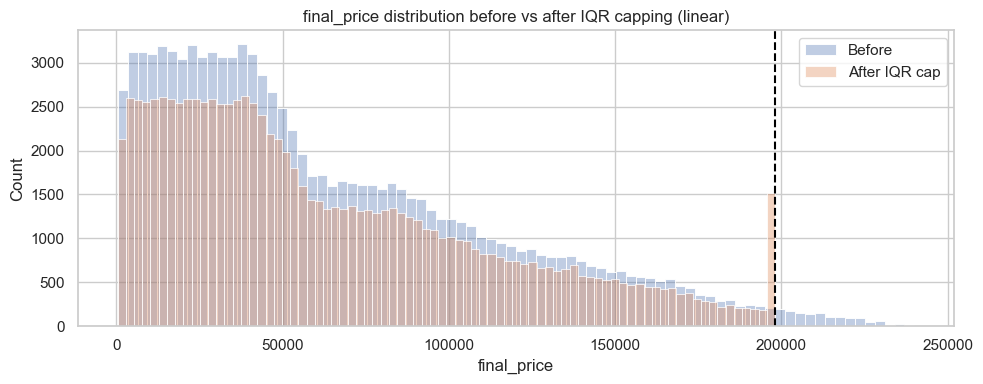

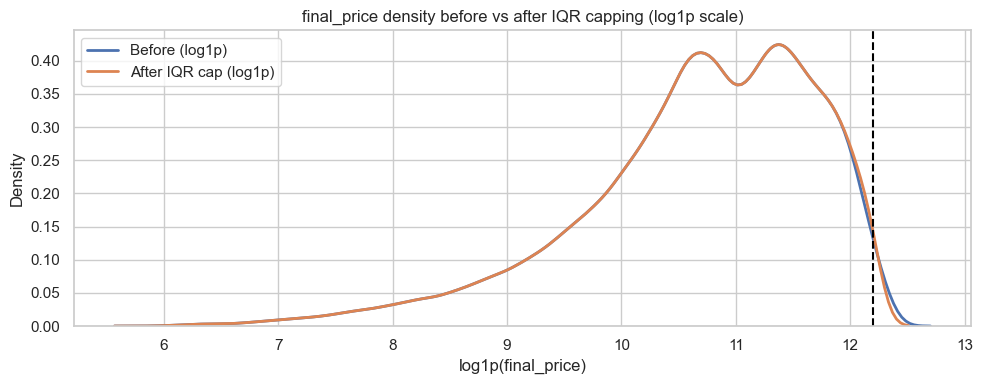

C:\Users\user\AppData\Local\Temp\ipykernel_22724\1203208936.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='version', y='value', palette=['#4c72b0', '#dd8452'])


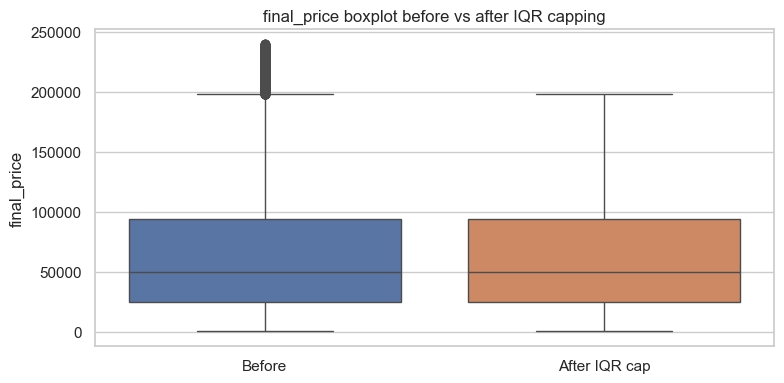

In [38]:
#effect of capping final_price at the IQR upper bound via before/after summaries and plots


sns.set_theme(style='whitegrid')

col_name = 'final_price'
q1_val = df[col_name].quantile(0.25)
q3_val = df[col_name].quantile(0.75)
iqr_val = q3_val - q1_val
upper_cap = q3_val + 1.5 * iqr_val
lower_cap = q1_val - 1.5 * iqr_val

series_before = df[col_name].astype(float)
series_after = series_before.clip(lower=lower_cap, upper=upper_cap)

n_capped_high = int((series_before > upper_cap).sum())
n_capped_low = int((series_before < lower_cap).sum())

pct_capped = (n_capped_high + n_capped_low) / len(series_before) * 100

print(upper_cap)
print(n_capped_high)
print(n_capped_low)
print(pct_capped)

summary_df = pd.DataFrame({
    'before': series_before.describe(),
    'after_iqr_cap': series_after.describe()
})
print(summary_df)

# Plot 1: distribution (linear scale) with cap line
plt.figure(figsize=(10, 4))
sns.histplot(series_before, bins=80, color='#4c72b0', alpha=0.35, label='Before')
sns.histplot(series_after, bins=80, color='#dd8452', alpha=0.35, label='After IQR cap')
plt.axvline(upper_cap, color='black', linestyle='--', linewidth=1.5)
plt.title('final_price distribution before vs after IQR capping (linear)')
plt.xlabel('final_price')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: distribution (log scale) to make tail visible
plt.figure(figsize=(10, 4))
sns.kdeplot(np.log1p(series_before), color='#4c72b0', linewidth=2, label='Before (log1p)')
sns.kdeplot(np.log1p(series_after), color='#dd8452', linewidth=2, label='After IQR cap (log1p)')
plt.axvline(np.log1p(upper_cap), color='black', linestyle='--', linewidth=1.5)
plt.title('final_price density before vs after IQR capping (log1p scale)')
plt.xlabel('log1p(final_price)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: boxplot before vs after
plt.figure(figsize=(8, 4))
plot_df = pd.DataFrame({
    'value': pd.concat([series_before, series_after], ignore_index=True),
    'version': (['Before'] * len(series_before)) + (['After IQR cap'] * len(series_after))
})
sns.boxplot(data=plot_df, x='version', y='value', palette=['#4c72b0', '#dd8452'])
plt.title('final_price boxplot before vs after IQR capping')
plt.xlabel('')
plt.ylabel('final_price')
plt.tight_layout()
plt.show()

###Before vs after: summary stats (key effects)
Capping mainly changes the extreme right tail without touching the middle of the distribution:

Mean

Before: 64,165.72
After cap: 63,978.84 Mean drops a bit because a small number of very large values got pulled down.
Std dev

Before: 49,969.28
After cap: 49,425.72 Dispersion decreases (tail is less extreme).
    Median and quartiles (25%, 50%, 75%)

Unchanged This is expected because only ~1.3% of points were modified and they were in the far right tail.
Max

Before: 239,980
After cap: 198,057.675 Max becomes exactly the cap.

Visual effects (what you should notice in the charts)
1) Histogram (linear scale)
 “After IQR cap” distribution looks very similar overall, but the far-right tail is truncated at the dashed vertical line (the cap). This makes the distribution less dominated by a few extreme purchases.

2) Density plot on log1p(final_price)
This is the clearest view: the capped version has a slightly lighter extreme-right tail, but otherwise overlaps heavily. This shows capping didn’t distort the bulk of the data.

3) Boxplot before vs after
The “after” boxplot shows far fewer extreme high-end fliers, and the upper whisker/outlier region is less stretched. The box (IQR) stays basically the same.

Capping at the IQR upper bound reduces the influence of the top ~1.3% of orders on averages/variance, while leaving typical orders (median and quartiles) essentially unchanged.

#Bivariate analysis

Numeric columns used:
['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days', 'year']

Categorical columns used:
['customer_id', 'gender', 'city', 'state', 'customer_segment', 'order_id', 'order_date', 'product_category', 'product_subcategory', 'payment_method', 'shipping_type', 'return_status']


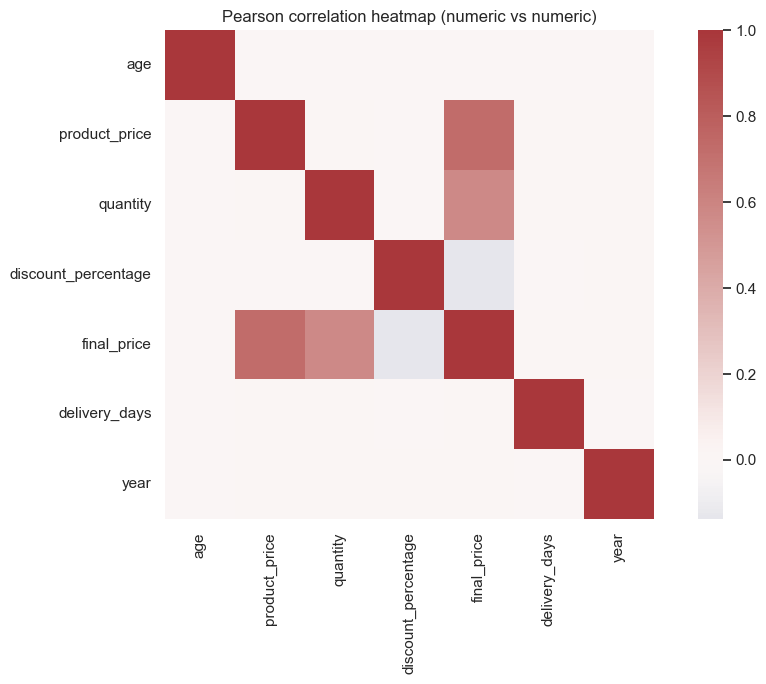

Top 10 absolute Pearson correlations:
                   var1                 var2      corr
29          final_price        product_price  0.730757
30          final_price             quantity  0.575303
25  discount_percentage          final_price -0.137332
41        delivery_days                 year -0.005027
34          final_price                 year  0.004232
3                   age  discount_percentage -0.004035
37        delivery_days             quantity  0.004017
5                   age        delivery_days -0.003954
39        delivery_days          final_price  0.003789
13        product_price                 year  0.003784


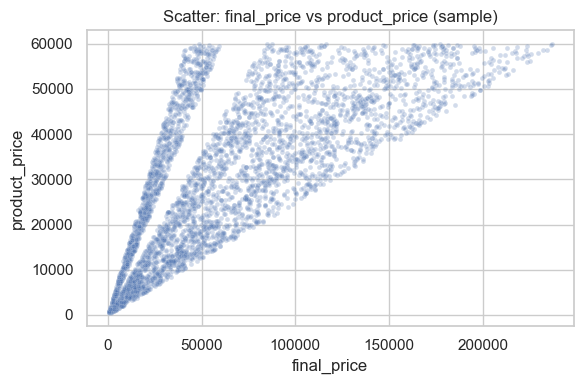

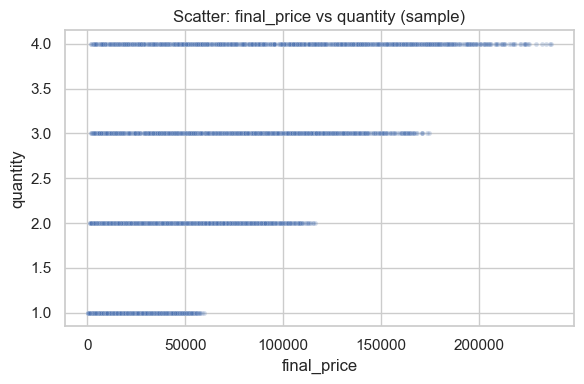

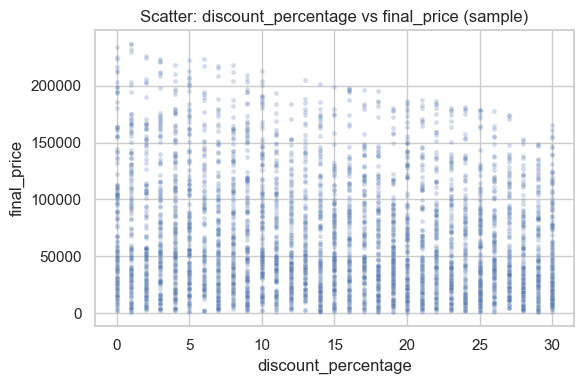


Top 12 Numeric vs Categorical relationships by eta-squared (variance explained):
            categorical              numeric  eta_squared
36  product_subcategory        product_price     0.000307
35  product_subcategory                  age     0.000218
40  product_subcategory        delivery_days     0.000196
41  product_subcategory                 year     0.000179
7                  city                  age     0.000178
14                state                  age     0.000178
37  product_subcategory             quantity     0.000166
10                 city  discount_percentage     0.000163
17                state  discount_percentage     0.000163
38  product_subcategory  discount_percentage     0.000144
39  product_subcategory          final_price     0.000143
12                 city        delivery_days     0.000111


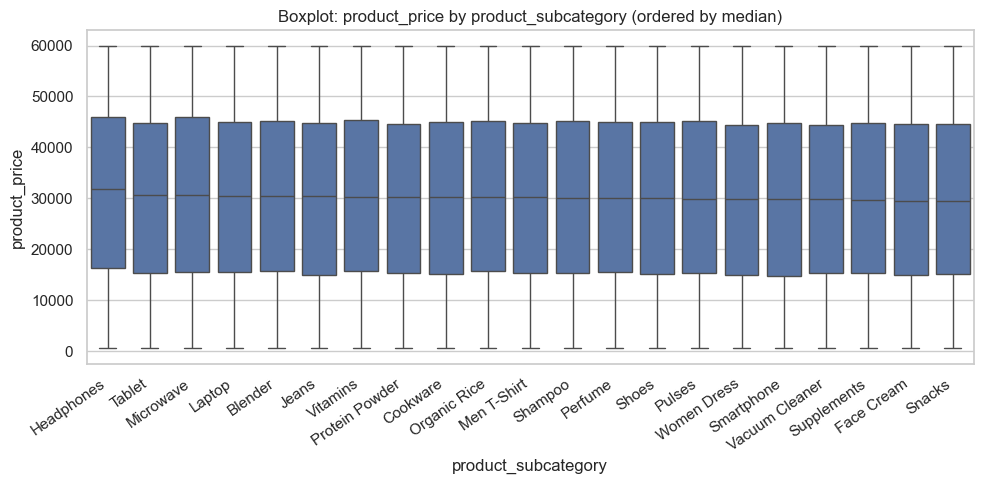

C:\Users\user\AppData\Local\Temp\ipykernel_22724\3834715002.py:114: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_tmp, x=best_cat, y=best_num, order=med_order, errorbar=('ci', 95), join=False)


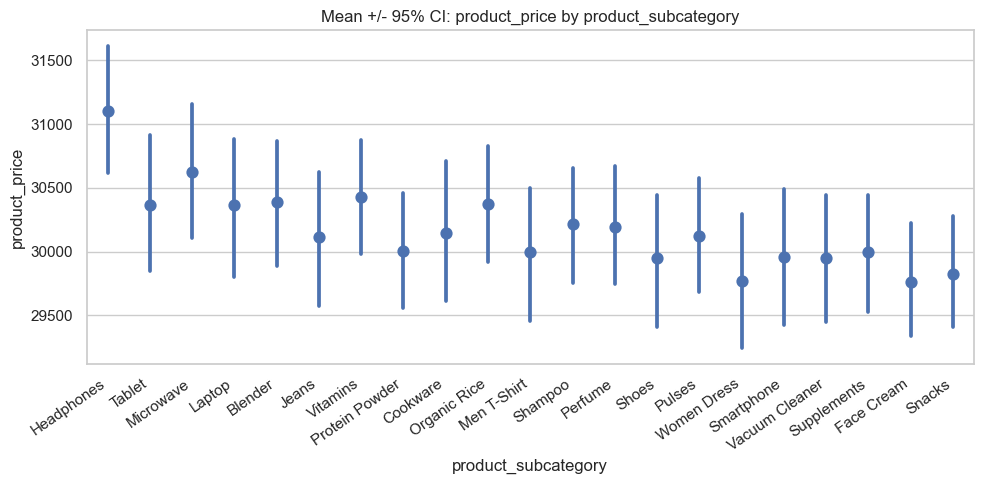

In [39]:
# Bivariate analysis utilities on the in-memory retail dataframe (df_retail)
# - Numeric vs Numeric: correlations + heatmap + a few top pairs
# - Numeric vs Categorical: group summaries + effect sizes (eta-squared) + plots



sns.set_theme(style='whitegrid')

# Identify numeric and categorical columns
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = df.select_dtypes(exclude=[np.number]).columns.tolist()

# For correlation, keep only numeric columns with at least some variance
num_cols = []
for col_name in num_cols_all:
    s = df[col_name]
    if s.notna().sum() > 10 and s.nunique(dropna=True) > 1:
        num_cols.append(col_name)

print('Numeric columns used:')
print(num_cols)
print('')
print('Categorical columns used:')
print(cat_cols_all)

# Correlation matrix
corr_df = df[num_cols].corr(method='pearson')

# Plot correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df, cmap='vlag', center=0, annot=False, square=True)
plt.title('Pearson correlation heatmap (numeric vs numeric)')
plt.tight_layout()
plt.show()

# Extract top absolute correlations excluding diagonal
corr_long = corr_df.stack().reset_index()
corr_long.columns = ['var1', 'var2', 'corr']
corr_long = corr_long[corr_long['var1'] < corr_long['var2']].copy()
corr_long['abs_corr'] = corr_long['corr'].abs()

corr_top = corr_long.sort_values('abs_corr', ascending=False).head(10)
print('Top 10 absolute Pearson correlations:')
print(corr_top[['var1','var2','corr']])

# Quick scatterplots for top 3 pairs (if there are enough numeric columns)
top_pairs = corr_top.head(3)
if len(top_pairs) > 0:
    for _, row in top_pairs.iterrows():
        x_col = row['var1']
        y_col = row['var2']
        sample_df = df[[x_col, y_col]].dropna().sample(n=min(4000, df[[x_col, y_col]].dropna().shape[0]), random_state=7)
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=sample_df, x=x_col, y=y_col, s=12, alpha=0.25)
        plt.title('Scatter: ' + x_col + ' vs ' + y_col + ' (sample)')
        plt.tight_layout()
        plt.show()

# Numeric vs categorical: eta-squared effect size for each (num, cat)
# eta^2 = SSB / SST using group means; measures how much variance in numeric is explained by the category.

def eta_squared(y_vals, groups_vals):
    tmp_df = pd.DataFrame({'y': y_vals, 'g': groups_vals}).dropna()
    if tmp_df.shape[0] < 10:
        return np.nan
    if tmp_df['g'].nunique() < 2:
        return np.nan
    overall_mean = tmp_df['y'].mean()
    sst = ((tmp_df['y'] - overall_mean) ** 2).sum()
    if sst == 0:
        return 0.0
    group_stats = tmp_df.groupby('g')['y'].agg(['count','mean'])
    ssb = (group_stats['count'] * (group_stats['mean'] - overall_mean) ** 2).sum()
    return float(ssb / sst)

# To keep it practical, only consider categorical columns with limited cardinality
cat_cols_limited = []
for col_name in cat_cols_all:
    nunq = df[col_name].nunique(dropna=True)
    if nunq >= 2 and nunq <= 30:
        cat_cols_limited.append(col_name)

eta_rows = []
for cat_col in cat_cols_limited:
    for num_col in num_cols:
        eta2_val = eta_squared(df[num_col], df[cat_col])
        eta_rows.append({'categorical': cat_col, 'numeric': num_col, 'eta_squared': eta2_val})

eta_df = pd.DataFrame(eta_rows).dropna().sort_values('eta_squared', ascending=False)

print('')
print('Top 12 Numeric vs Categorical relationships by eta-squared (variance explained):')
print(eta_df.head(12))

# Plot for the strongest numeric-vs-categorical pair
if eta_df.shape[0] > 0:
    best_cat = eta_df.iloc[0]['categorical']
    best_num = eta_df.iloc[0]['numeric']

    plot_tmp = df[[best_cat, best_num]].dropna().copy()

    # Order categories by median to make plot readable
    med_order = plot_tmp.groupby(best_cat)[best_num].median().sort_values(ascending=False).index

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=plot_tmp, x=best_cat, y=best_num, order=med_order)
    plt.title('Boxplot: ' + best_num + ' by ' + best_cat + ' (ordered by median)')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

    # Also show mean with CI style pointplot (more readable for many categories)
    plt.figure(figsize=(10, 5))
    sns.pointplot(data=plot_tmp, x=best_cat, y=best_num, order=med_order, errorbar=('ci', 95), join=False)
    plt.title('Mean +/- 95% CI: ' + best_num + ' by ' + best_cat)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

1) Numerical vs Numerical: 

Step 1: Compute correlation matrix

Used Pearson for linear relationships and also run Spearman if you suspect monotonic but non-linear patterns or heavy outliers
Step 2: Visualize

A correlation heatmap to see the big picture quickly
A scatterplot  for the strongest pairs, because correlation alone can hide non-linear patterns and outlier-driven relationships

From the correlations we computed:

final_price vs product_price had a strong positive correlation (~0.73)
final_price vs quantity had a moderate positive correlation (~0.58)
discount_percentage vs final_price was weak negative (~-0.14)
Interpretation: totally intuitive—final spend increases with price and quantity; discounts slightly reduce final price on average.

Plotted the top correlated pairs to confirm you’re not being fooled by outliers or weird clustering.

2) Numerical vs Categorical: 

Step 1: Summarize the numeric variable by category

Compared mean/median across groups
Looked at spread (IQR / std) per group

Step 2: Visualize
Boxplot shows median, IQR, outliers
Point plot of means with confidence intervals is great for a clean “differences in average” view



Interpretation: in this dataset as-is, categorical fields like product_subcategory, city, etc. don’t explain much variance in numeric measures (like product_price, age, delivery_days). That can happen if:

the numeric outcomes are broadly similar across categories,
or the category definitions don’t strongly segment the numeric behavior,
or noise dominates.
plotted the strongest numeric-vs-categorical pair . Visually, these is heavy overlap between categories 

In [40]:
#multivariate analysis

['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days', 'year', 'returned_flag']


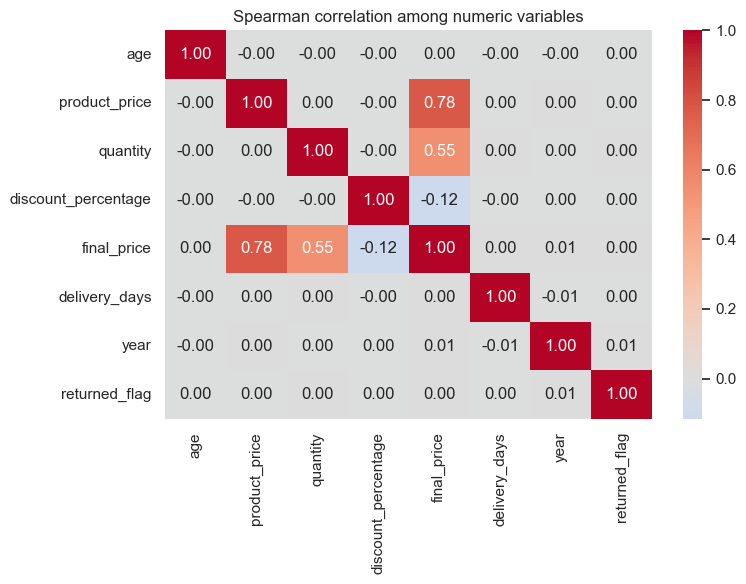

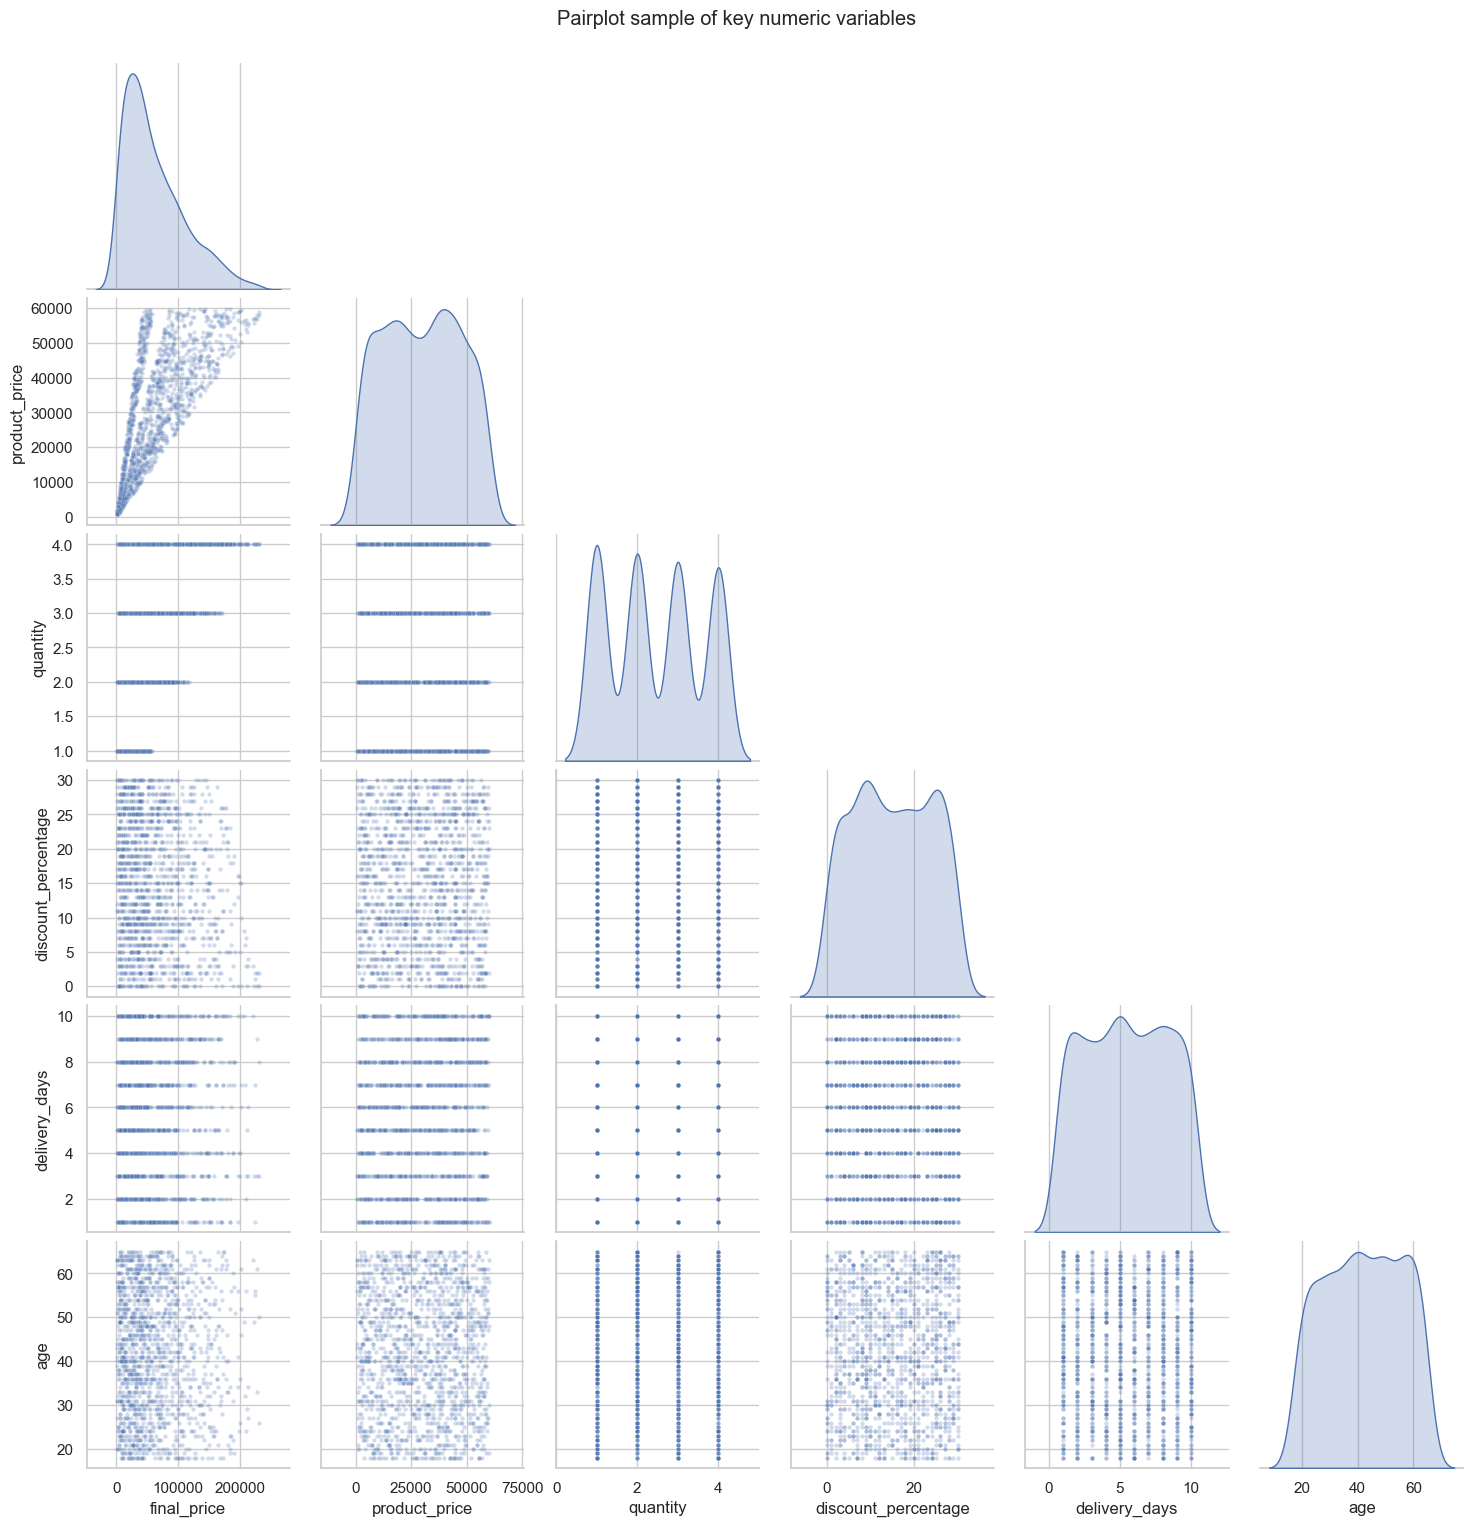

In [41]:
# Multivariate analysis starter pack for this dataset:
# 1) Correlations/relationships among numeric variables
# 2) Pairplot sample for quick joint distributions
# 3) Multiple regression: what drives final_price
# 4) Classification: what drives return_status



sns.set_theme(style='whitegrid')

# Ensure engineered target/utility columns exist
if 'return_status' in df.columns:
    df['returned_flag'] = (df['return_status'].astype(str).str.lower() == 'yes').astype(int)

# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(num_cols)

# Correlation heatmap (Spearman is more robust to skew/outliers)
corr_spearman = df[num_cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Spearman correlation among numeric variables')
plt.tight_layout()
plt.show()

# Pairplot on a sample so it renders fast
pair_cols = [c for c in ['final_price', 'product_price', 'quantity', 'discount_percentage', 'delivery_days', 'age'] if c in df.columns]
df_pair = df[pair_cols].sample(1500, random_state=42)

g = sns.pairplot(df_pair, diag_kind='kde', corner=True, plot_kws={'alpha': 0.25, 's': 10})
g.fig.suptitle('Pairplot sample of key numeric variables', y=1.02)
plt.show()

What “multivariate analysis” means 

R² ≈ 0.882 meaning the model explains about 88% of the variation in final_price
MAE ≈ 12,885 (average absolute error in your currency units)
Multiple regression for final_price works very well (high R²)
Classification for return_status doesn’t work with current features (AUC ~ 0.5)





In [42]:
#fitting regressinal model

0.8822
12885.19


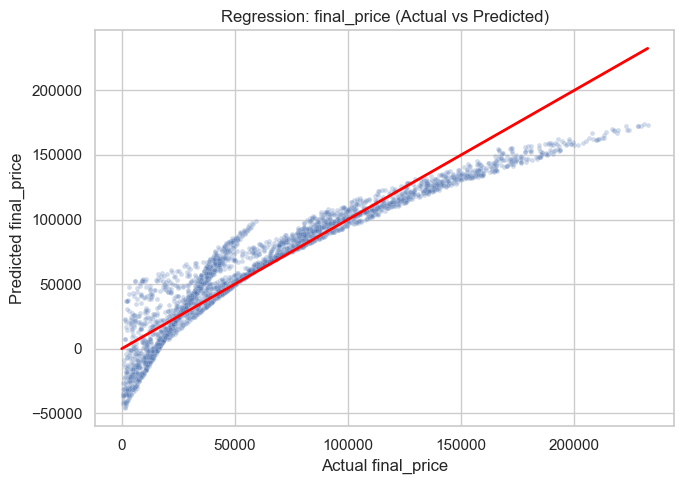

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.4959


<Figure size 600x500 with 0 Axes>

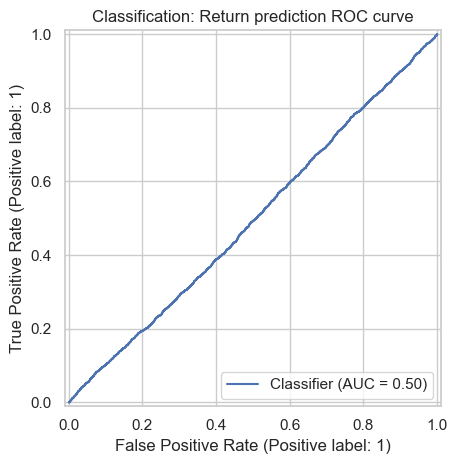

In [43]:
# Fit two multivariate models:
# A) Multiple regression to explain final_price
# B) Logistic regression to explain returns (returned_flag)



from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import roc_auc_score, RocCurveDisplay

sns.set_theme(style='whitegrid')

# Feature set (mix numeric + categorical)
feature_cols = [
    'age','gender','state','customer_segment','product_category','product_subcategory',
    'product_price','quantity','discount_percentage','payment_method','shipping_type','delivery_days'
]
feature_cols = [c for c in feature_cols if c in df.columns]

X_all = df[feature_cols].copy()
num_features = X_all.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in feature_cols if c not in num_features]

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_features),
        ('cat', categorical_pipe, cat_features)
    ],
    remainder='drop'
)

# A) Regression
if 'final_price' in df.columns:
    y_reg = df['final_price'].copy()
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_reg, test_size=0.2, random_state=42)

    reg_model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LinearRegression())
    ])
    reg_model.fit(X_train, y_train)

    y_pred = reg_model.predict(X_test)
    r2_val = r2_score(y_test, y_pred)
    mae_val = mean_absolute_error(y_test, y_pred)

    print(round(r2_val, 4))
    print(round(mae_val, 2))

    # Plot predicted vs actual
    plot_df = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred})
    plot_df = plot_df.sample(3000, random_state=42) if len(plot_df) > 3000 else plot_df

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x='actual', y='predicted', alpha=0.25, s=12)
    max_val = np.nanmax([plot_df['actual'].max(), plot_df['predicted'].max()])
    plt.plot([0, max_val], [0, max_val], color='red', linewidth=2)
    plt.title('Regression: final_price (Actual vs Predicted)')
    plt.xlabel('Actual final_price')
    plt.ylabel('Predicted final_price')
    plt.tight_layout()
    plt.show()

# B) Classification
if 'returned_flag' in df.columns:
    y_clf = df['returned_flag'].copy()
    X_train2, X_test2, y_train2, y_test2 = train_test_split(X_all, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

    clf_model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=1000, n_jobs=None))
    ])
    clf_model.fit(X_train2, y_train2)

    proba = clf_model.predict_proba(X_test2)[:, 1]
    auc_val = roc_auc_score(y_test2, proba)
    print(round(auc_val, 4))

    plt.figure(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test2, proba)
    plt.title('Classification: Return prediction ROC curve')
    plt.tight_layout()
    plt.show()

In [44]:
#Skewness and Kurtosis Interpretation

In [45]:
# Compute skewness/kurtosis by customer_segment using a robust groupby-apply approach
import pandas as pd
import numpy as np

numeric_cols2 = df.select_dtypes(include=[np.number]).columns.tolist()

seg_summary_flat = None
if 'customer_segment' in df.columns:
    seg_parts = []
    for seg_name, seg_df in df.groupby('customer_segment'):
        seg_stats = pd.DataFrame({
            'metric': numeric_cols2,
            'mean': [seg_df[c].mean() for c in numeric_cols2],
            'median': [seg_df[c].median() for c in numeric_cols2],
            'skewness': [seg_df[c].skew() for c in numeric_cols2],
            'excess_kurtosis': [seg_df[c].kurt() for c in numeric_cols2]
        })
        seg_stats['customer_segment'] = seg_name
        seg_parts.append(seg_stats)
    seg_summary_flat = pd.concat(seg_parts, ignore_index=True)
    print(seg_summary_flat.head())

    seg_out_path = './skew_kurtosis_by_customer_segment.csv'
    seg_summary_flat.to_csv(seg_out_path, index=False)
    print(seg_out_path)

                metric          mean    median  skewness  excess_kurtosis  \
0                  age     41.585613     42.00 -0.010470        -1.200361   
1        product_price  29995.404623  29908.00  0.016296        -1.186723   
2             quantity      2.497074      2.00  0.003812        -1.364822   
3  discount_percentage     14.970497     15.00  0.010538        -1.198186   
4          final_price  63766.749294  49224.52  0.949813         0.202362   

  customer_segment  
0              New  
1              New  
2              New  
3              New  
4              New  
./skew_kurtosis_by_customer_segment.csv


Skewness and kurtosis — what they mean (client-friendly interpretation)
Skewness tells you whether a numeric feature is symmetric or has a long tail:

Skewness ≈ 0: roughly symmetric
Skewness > 0: right-skewed (a few very large values; common in spending / revenue)
Skewness < 0: left-skewed (a few very small values)

∣skew∣<0.5 → approximately symmetric

0.5≤∣skew∣<1.0 → moderately skewed

∣skew∣≥1.0 → highly skewed

Excess kurtosis ≈ 0: normal-like tail behavior
> 0: heavy-tailed (more extreme outliers than normal)
< 0: light-tailed (fewer outliers than normal)

excess kurtosis < -0.5 → light tails
-0.5 to +0.5 → near normal
+0.5 → heavy tails (outlier-prone)

What your dataset is showing (based on computed results)
From the skew/kurt calculations on your numeric columns (and also derived metrics like gross_amount and discount_amount):

1) Monetary variables are not normally distributed
final_price is positively skewed (right-skewed). In the segment-level stats, for example, New customers show final_price skewness ~ 0.95, which is meaningfully right-skewed.

2) Heavy tails show outlier risk in spend/discount-related metrics
The derived discount_amount is highly skewed and leptokurtic (heavy-tailed). In plain terms: most discounts are modest, but there are some extreme discount values (typically driven by high price × quantity × discount%).
